In [1]:
!pip install numpy==2.3.5

In [2]:
%reload_ext watermark
%watermark -v -p pandas,numpy,geopandas,libpysal,esda,spreg,contextily,splot,scipy,matplotlib

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

pandas    : 3.0.1
numpy     : 2.3.5
geopandas : 1.1.2
libpysal  : 4.14.1
esda      : 2.8.1
spreg     : 1.8.5
contextily: 1.7.0
splot     : 1.1.7
scipy     : 1.17.0
matplotlib: 3.10.8



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import seaborn as sns
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from scipy import stats
from shapely.geometry import Point
from splot.esda import moran_scatterplot, plot_moran
import contextily as ctx
from matplotlib.ticker import FuncFormatter
import pyproj
from libpysal.weights import lag_spatial
from scipy.stats import norm

In [4]:
df = pd.read_csv('D:/Glasgow/advanced topic for urban amalytics/listings.csv.gz')

In [5]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,15420,https://www.airbnb.com/rooms/15420,20250921034137,2025-09-21,city scrape,Georgian Boutique Apt City Centre,"Stunning, spacious ground floor apartment minu...","The neighbourhood is in the historic New Town,...",https://a0.muscache.com/pictures/cf69631f-4194...,60423,...,4.99,4.98,4.92,NaN,f,1,1,0,0,3.62
1,24288,https://www.airbnb.com/rooms/24288,20250921034137,2025-09-21,city scrape,"Cool central Loft, sleeps 4, 2 double bed+en-s...",Upper level of duplex. Boho rustic-chic former...,"Boho, studenty, lively, cool neighbourhood",https://a0.muscache.com/pictures/3460007/88731...,46498,...,4.92,4.85,4.67,NaN,f,1,1,0,0,2.17
2,38628,https://www.airbnb.com/rooms/38628,20250921034137,2025-09-21,city scrape,Edinburgh Holiday Let,Self contained studio 6 minutes by train to Ed...,Quiet and easy access to outside. Fort Kinnair...,https://a0.muscache.com/pictures/hosting/Hosti...,165635,...,4.77,4.72,4.75,EH-70886-F,f,1,1,0,0,0.55
3,44552,https://www.airbnb.com/rooms/44552,20250921034137,2025-09-21,city scrape,Double room - spacious Leith flat,NaN,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,195950,...,4.88,4.71,4.77,NaN,f,1,0,1,0,1.73
4,54188,https://www.airbnb.com/rooms/54188,20250921034137,2025-09-21,city scrape,The Four Sisters Boatel,"A first for Scotland, The Four Sisters Boatel ...",The Four Sisters Boatel Is moored in The Lochr...,https://a0.muscache.com/pictures/868604d2-7951...,253850,...,4.66,4.79,4.36,NaN,t,3,3,0,0,0.23


In [6]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [7]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [8]:
cols = [
    'id', 'latitude', 'longitude', 'price',
    'room_type', 'accommodates', 'bedrooms', 'bathrooms_text',
    'host_is_superhost', 'instant_bookable',
    'reviews_per_month',
    'review_scores_rating',
    'availability_365', 'minimum_nights',
    'neighbourhood_cleansed'
]

df_clean = df[cols].copy()

In [9]:
df_clean['bathrooms'] = df_clean['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
df_clean = df_clean.drop(columns='bathrooms_text')

df_clean['is_superhost'] = (df_clean['host_is_superhost'] == 't').astype(int)
df_clean['is_instant_bookable'] = (df_clean['instant_bookable'] == 't').astype(int)
df_clean = df_clean.drop(columns=['host_is_superhost', 'instant_bookable'])

room_dummies = pd.get_dummies(df_clean['room_type'], prefix='room', drop_first=False)

if 'room_Entire home/apt' in room_dummies.columns:
    room_dummies = room_dummies.drop(columns='room_Entire home/apt')
df_clean = pd.concat([df_clean, room_dummies], axis=1)

In [10]:
key_cols = ['price', 'latitude', 'longitude', 'bedrooms',
            'bathrooms', 'review_scores_rating', 'accommodates',
            'reviews_per_month', 'availability_365', 'minimum_nights',
            'is_superhost', 'is_instant_bookable']
df_clean = df_clean.dropna(subset=key_cols)

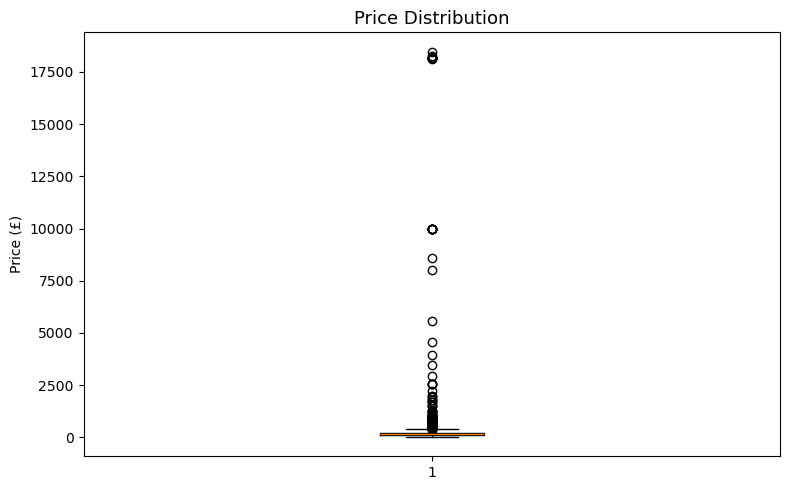

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df_clean['price'], vert=True)
ax.set_title('Price Distribution', fontsize=13)
ax.set_ylabel('Price (£)')

plt.tight_layout()
plt.show()

In [12]:
price_99th = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= price_99th]
df_clean = df_clean.reset_index(drop=True)

print(f"99th percentile price: £{price_99th:.2f}")
print(f"After removing top 1%: {len(df_clean)} listings")

99th percentile price: £1539.18
After removing top 1%: 4553 listings


In [13]:
df_clean['log_price'] = np.log(df_clean['price'])

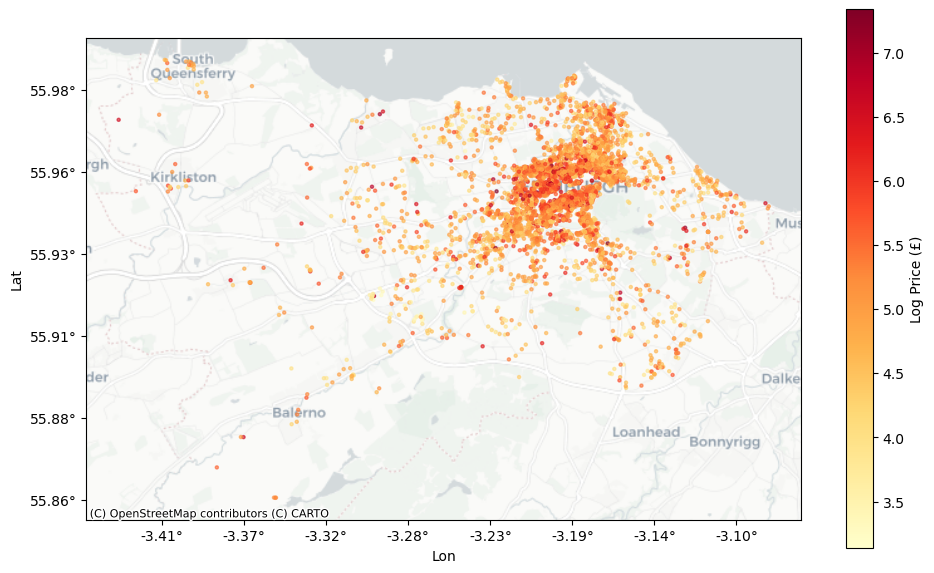

In [14]:
geometry = [Point(xy) for xy in zip(df_clean['longitude'], df_clean['latitude'])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs='EPSG:4326')

gdf_web = gdf.to_crs('EPSG:3857')

fig, ax = plt.subplots(figsize=(10, 8))

gdf_web.plot(
    ax=ax, column='log_price', cmap='YlOrRd',
    markersize=5, alpha=0.6, legend=True,
    legend_kwds={'label': 'Log Price (£)', 'shrink': 0.7}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_xlabel('Lon')
ax.set_ylabel('Lat')

transformer = pyproj.Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

def lon_formatter(x, pos):
    lon, _ = transformer.transform(x, 0)
    return f'{lon:.2f}°'

def lat_formatter(y, pos):
    _, lat = transformer.transform(0, y)
    return f'{lat:.2f}°'

ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

plt.tight_layout()
plt.show()

In [15]:
gdf_proj = gdf.to_crs('EPSG:27700')
coords = np.column_stack((gdf_proj.geometry.x, gdf_proj.geometry.y))

w_knn = KNN.from_array(coords, k=5)
w_knn.transform = 'R'  

print("=== KNN Spatial Weights (k=5) ===")
print(f"Number of observations: {w_knn.n}")
print(f"Mean number of neighbours: {w_knn.mean_neighbors:.1f}")
print(f"Min neighbours: {w_knn.min_neighbors}")
print(f"Max neighbours: {w_knn.max_neighbors}")


=== KNN Spatial Weights (k=5) ===
Number of observations: 4553
Mean number of neighbours: 5.0
Min neighbours: 5
Max neighbours: 5


C:\Users\18095\anaconda3\envs\spatial-regression\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [16]:
y_col = 'log_price'
y = df_clean[[y_col]].values

room_dummy_cols = [c for c in df_clean.columns if c.startswith('room_') and c != 'room_type']

x_cols = [
    'accommodates', 'bedrooms', 'bathrooms',
    'is_superhost', 'review_scores_rating', 'reviews_per_month',
    'availability_365', 'minimum_nights',
    'is_instant_bookable'
] + room_dummy_cols

for col in room_dummy_cols:
    df_clean[col] = df_clean[col].astype(int)

x = df_clean[x_cols].values

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_clean[x_cols] 

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
                Variable        VIF
0           accommodates  15.585832
1               bedrooms  14.925287
4   review_scores_rating  13.437113
2              bathrooms   9.146834
6       availability_365   3.129843
5      reviews_per_month   2.638787
3           is_superhost   2.067593
8    is_instant_bookable   1.826639
10     room_Private room   1.755181
7         minimum_nights   1.069965
11      room_Shared room   1.018634
9        room_Hotel room   1.017274
----------------------------------------
Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.


#### Variance Inflation Factor (VIF) was calculated to assess multicollinearity among the explanatory variables. The results indicated that accommodates (VIF = 15.59), bedrooms (VIF = 14.93), and review_scores_rating (VIF = 13.44) exceeded the commonly accepted threshold of 10, suggesting potential multicollinearity.

#### As accommodates is highly correlated with structural housing characteristics such as bedrooms and bathrooms, it was removed from the regression model to reduce redundancy. Retaining the structural variables allows the model to better capture the physical characteristics of the property. 

In [18]:
x_cols_update = [
    'bedrooms', 'bathrooms',
    'is_superhost', 'review_scores_rating', 'reviews_per_month',
    'availability_365', 'minimum_nights',
    'is_instant_bookable'
] + room_dummy_cols

X_vif = df_clean[x_cols_update] 

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
                Variable        VIF
3   review_scores_rating  13.033867
1              bathrooms   8.911169
0               bedrooms   7.244432
5       availability_365   3.106020
4      reviews_per_month   2.638221
2           is_superhost   2.065694
7    is_instant_bookable   1.823252
9      room_Private room   1.618848
6         minimum_nights   1.069516
10      room_Shared room   1.016879
8        room_Hotel room   1.015194
----------------------------------------
Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.


#### However, *review_scores_rating* still had a high VIF (13.03), so it was removed as well to ensure model stability.  The remaining predictors—*bedrooms*, *bathrooms*, *availability_365*, *reviews_per_month*, *is_superhost*, *is_instant_bookable*, *minimum_nights*, and room type dummies—show acceptable VIF values (<10), indicating that multicollinearity has been sufficiently controlled. This variable selection ensures reliable coefficient estimates for the subsequent OLS and spatial regression models.

In [19]:
x_cols_update = [
    'bedrooms', 'bathrooms',
    'is_superhost', 'reviews_per_month',
    'availability_365', 'minimum_nights',
    'is_instant_bookable'
] + room_dummy_cols

X_vif = df_clean[x_cols_update] 

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Check:")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))
print("-" * 40)
print("Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.")

Variance Inflation Factor (VIF) Check:
----------------------------------------
              Variable       VIF
1            bathrooms  8.004320
0             bedrooms  6.604675
4     availability_365  2.724281
3    reviews_per_month  2.217437
2         is_superhost  1.842242
6  is_instant_bookable  1.763463
8    room_Private room  1.344693
5       minimum_nights  1.057264
7      room_Hotel room  1.014551
9     room_Shared room  1.013000
----------------------------------------
Note: VIF > 10 indicates high multicollinearity that may distort spatial coefficients.


#### Now it looks okay with all VIFs below 10, indicating that multicollinearity is no longer a concern for our regression analysis.

In [20]:
x_cols = x_cols_update
x = df_clean[x_cols].values

In [21]:
ols = OLS(
    y, x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb',
    spat_diag=True  # Request spatial diagnostics including LM tests
)

print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :Edinburgh Airbnb
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4553
Mean dependent var  :      5.0781                Number of Variables   :          11
S.D. dependent var  :      0.6159                Degrees of Freedom    :        4542
R-squared           :      0.4942
Adjusted R-squared  :      0.4931
Sum squared residual:     873.422                F-statistic           :    443.8306
Sigma-square        :       0.192                Prob(F-statistic)     :           0
S.E. of regression  :       0.439                Log likelihood        :   -2701.647
Sigma-square ML     :       0.192                Akaike info criterion :    5425.295
S.E of regression ML:      0.4380                Schwarz criterion     :    5495.954

--------------------------------------------------------

#### The OLS regression was run on 4,553 Airbnb listings with log-transformed price as the dependent variable. The model explained approximately 49% of the variation in listing prices (R² = 0.494). All explanatory variables were statistically significant at the 1% level.

#### Key findings:
#### 1.Structural characteristics (bedrooms and bathrooms) and host attributes (is_superhost, is_instant_bookable) have positive effects on price.
#### 2.Room type significantly affects price, with private rooms and hotel rooms priced substantially lower than entire homes/apartments.
#### 3.Some activity measures (reviews_per_month, minimum_nights) show negative effects, whereas availability_365 has a small positive effect.

#### Diagnostics indicate that:
#### 1.Multicollinearity is acceptable (Condition Number = 9.285)
#### 2.Residuals are non-normal (Jarque-Bera p < 0.01)
#### 3.Heteroskedasticity is present (Breusch-Pagan and Koenker-Bassett tests, p < 0.01)
#### 4.Spatial dependence is highly significant (LM and SDM tests, p < 0.01)

#### These results suggest that while OLS provides an overall baseline model, spatial regression (SAR, SEM, or SDM) and GWR/mGWR are necessary to account for spatial autocorrelation and heteroskedasticity in Airbnb prices.

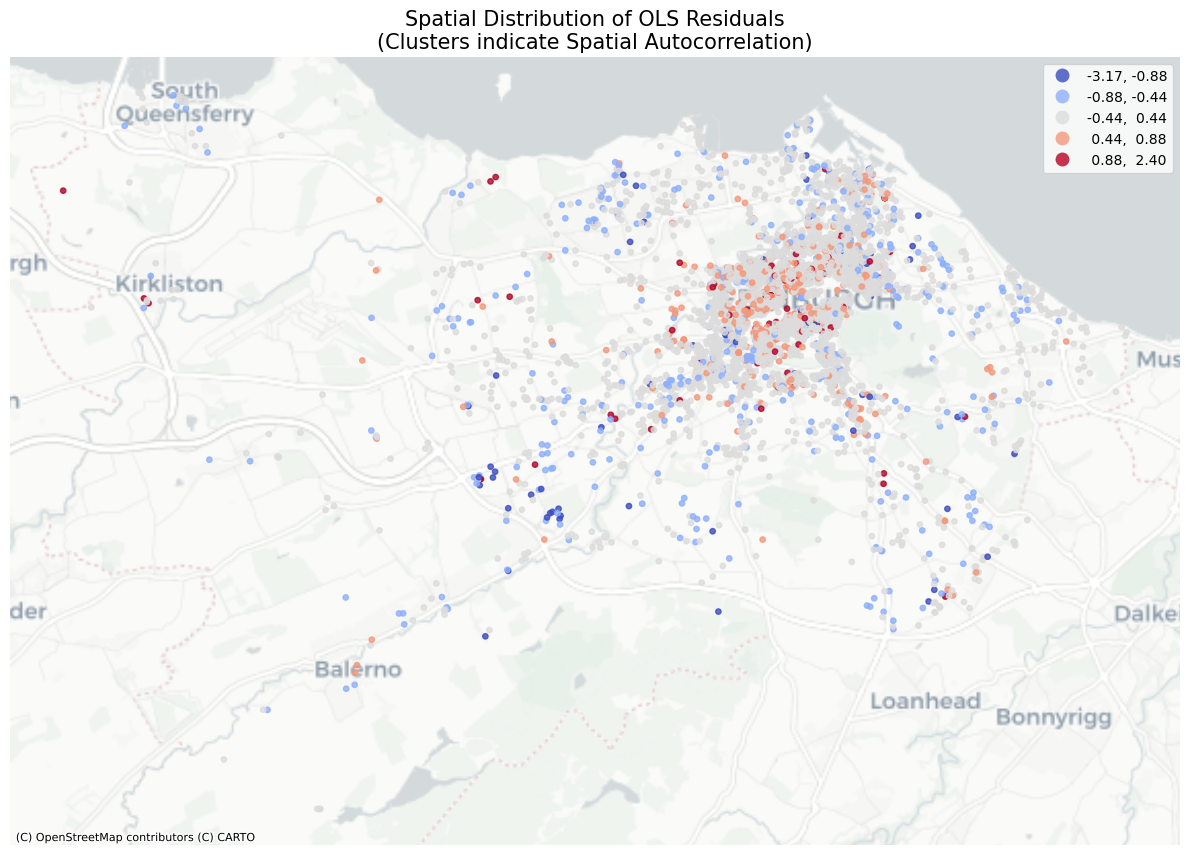

In [22]:
df_clean['ols_residuals'] = ols.u 

gdf_res = gpd.GeoDataFrame(
    df_clean, 
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude), 
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 10))

gdf_res_proj = gdf_res.to_crs(epsg=3857)

gdf_res_proj.plot(
    column='ols_residuals', 
    scheme='std_mean', # Standard deviation from mean highlights outliers well
    k=5, 
    cmap='coolwarm',   # Red = High/Positive, Blue = Low/Negative
    legend=True, 
    ax=ax, 
    markersize=15, 
    alpha=0.8
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title('Spatial Distribution of OLS Residuals\n(Clusters indicate Spatial Autocorrelation)', fontsize=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [23]:
residuals = ols.u.flatten()
moran = Moran(residuals, w_knn)

print("=== Global Moran's I Test on OLS Residuals ===")
print(f"Moran's I:     {moran.I:.4f}")
print(f"Expected I:    {moran.EI:.4f}")
print(f"Z-score:       {moran.z_sim:.4f}")
print(f"P-value:       {moran.p_sim:.4f}")
print()

=== Global Moran's I Test on OLS Residuals ===
Moran's I:     0.3212
Expected I:    -0.0002
Z-score:       36.6346
P-value:       0.0010



#### Global Moran’s I was computed on the residuals of the OLS model. The result shows Moran’s I = 0.3212 (Z = 36.04, p < 0.01), indicating strong and statistically significant positive spatial autocorrelation. This means that geographically close Airbnb listings tend to have similar price deviations from the OLS predictions.

#### Such spatial dependence violates the OLS assumption of independent residuals and suggests that spatial regression models (e.g., SAR, SEM) or geographically weighted regression (GWR/mGWR) are required to properly account for the spatial structure of Airbnb prices in Edinburgh.

In [24]:
sem = ML_Error(
    y,
    x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb (SEM)'
)

print(sem.summary)

C:\Users\18095\anaconda3\envs\spatial-regression\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :Edinburgh Airbnb (SEM)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4553
Mean dependent var  :      5.0781                Number of Variables   :          11
S.D. dependent var  :      0.6159                Degrees of Freedom    :        4542
Pseudo R-squared    :      0.4912
Log likelihood      :  -2268.3973
Sigma-square ML     :      0.1507                Akaike info criterion :    4558.795
S.E of regression   :      0.3882                Schwarz criterion     :    4629.454

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         4

In [25]:
sar = ML_Lag(
    y, x,
    w=w_knn,
    name_y=y_col,
    name_x=x_cols,
    name_ds='Edinburgh Airbnb (SAR)'
)

print(sar.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Edinburgh Airbnb (SAR)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4553
Mean dependent var  :      5.0781                Number of Variables   :          12
S.D. dependent var  :      0.6159                Degrees of Freedom    :        4541
Pseudo R-squared    :      0.5852
Spatial Pseudo R-squared:  0.4846
Log likelihood      :  -2318.2189
Sigma-square ML     :      0.1574                Akaike info criterion :    4660.438
S.E of regression   :      0.3968                Schwarz criterion     :    4737.520

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------

In [26]:
wx_cols = ['W_' + col for col in x_cols]
wx_array = np.column_stack([lag_spatial(w_knn, x[:, i]) for i in range(x.shape[1])])

x_sdm = np.hstack([x, wx_array])
x_sdm_names = x_cols + wx_cols

In [27]:
sdm = ML_Lag(
    y, x_sdm,
    w=w_knn,
    name_y=y_col,
    name_x=x_sdm_names,
    name_ds='Edinburgh Airbnb (SDM)'
)

print(sdm.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :Edinburgh Airbnb (SDM)
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:        4553
Mean dependent var  :      5.0781                Number of Variables   :          22
S.D. dependent var  :      0.6159                Degrees of Freedom    :        4531
Pseudo R-squared    :      0.6085
Spatial Pseudo R-squared:  0.5162
Log likelihood      :  -2224.7266
Sigma-square ML     :      0.1488                Akaike info criterion :    4493.453
S.E of regression   :      0.3857                Schwarz criterion     :    4634.771

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------------------

In [28]:
print("=" * 60)
print("LIKELIHOOD RATIO (LR) TESTS")
print("=" * 60)

lr_sdm_sar = -2 * (sar.logll - sdm.logll)
df_diff_sar = len(x_cols)  # number of WX variables added
p_sdm_sar = 1 - stats.chi2.cdf(lr_sdm_sar, df_diff_sar)

print(f"\nLR Test: SDM vs SAR")
print(f"  H0: θ = 0 (spatially lagged X variables are unnecessary)")
print(f"  LR statistic: {lr_sdm_sar:.4f}")
print(f"  Degrees of freedom: {df_diff_sar}")
print(f"  P-value: {p_sdm_sar:.4f}")
if p_sdm_sar < 0.05:
    print("  → Reject H0: SDM is preferred over SAR")
else:
    print("  → Cannot reject H0: SAR is sufficient (SDM not needed)")

lr_sdm_sem = -2 * (sem.logll - sdm.logll)
df_diff_sem = len(x_cols) + 1  # WX terms + rho
p_sdm_sem = 1 - stats.chi2.cdf(lr_sdm_sem, df_diff_sem)

print(f"\nLR Test: SDM vs SEM")
print(f"  H0: θ + ρβ = 0 (common factor hypothesis)")
print(f"  LR statistic: {lr_sdm_sem:.4f}")
print(f"  Degrees of freedom: {df_diff_sem}")
print(f"  P-value: {p_sdm_sem:.4f}")
if p_sdm_sem < 0.05:
    print("  → Reject H0: SDM is preferred over SEM")
else:
    print("  → Cannot reject H0: SEM is sufficient (SDM not needed)")

print("\n" + "=" * 60)
print("FINAL MODEL RECOMMENDATION")
print("=" * 60)
if p_sdm_sar < 0.05 and p_sdm_sem < 0.05:
    print("→ SDM is preferred: Both SAR and SEM are rejected in favour of SDM.")
elif p_sdm_sar >= 0.05 and p_sdm_sem < 0.05:
    print("→ SAR is preferred: SDM does not significantly improve over SAR.")
elif p_sdm_sar < 0.05 and p_sdm_sem >= 0.05:
    print("→ SEM is preferred: SDM does not significantly improve over SEM.")
else:
    print("→ Either SAR or SEM may be sufficient. Choose based on AIC and theory.")

LIKELIHOOD RATIO (LR) TESTS

LR Test: SDM vs SAR
  H0: θ = 0 (spatially lagged X variables are unnecessary)
  LR statistic: 186.9846
  Degrees of freedom: 10
  P-value: 0.0000
  → Reject H0: SDM is preferred over SAR

LR Test: SDM vs SEM
  H0: θ + ρβ = 0 (common factor hypothesis)
  LR statistic: 87.3415
  Degrees of freedom: 11
  P-value: 0.0000
  → Reject H0: SDM is preferred over SEM

FINAL MODEL RECOMMENDATION
→ SDM is preferred: Both SAR and SEM are rejected in favour of SDM.


#### Based on the likelihood ratio test results, the SDM model outperforms both SAR and SEM. In the comparison between SDM and SAR, the LR statistic is 186.98 with a p-value of 0.000, significantly rejecting the null hypothesis that spatially lagged independent variables are unnecessary, indicating that including them substantially improves model fit. In the comparison between SDM and SEM, the LR statistic is 87.34 with a p-value of 0.000, showing that considering only spatial error is insufficient to capture spatial effects. Overall, the SDM model effectively accounts for both spatial dependence in the dependent variable and spatially lagged effects of independent variables, and is thus recommended as the preferred model for this analysis.

In [29]:
def get_coefs(model, names):
    coefs = {}
    for i, name in enumerate(names):
        beta = model.betas[i][0] if hasattr(model.betas[i], '__len__') else model.betas[i]
        try:
            # Try z_stat first (spatial models), then t_stat (OLS)
            if hasattr(model, 'z_stat'):
                p = model.z_stat[i][1]
            else:
                p = model.t_stat[i][1]
            sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        except:
            sig = ''
        coefs[name] = f"{beta:.4f}{sig}"
    return coefs

In [30]:
var_names = ['CONSTANT'] + x_cols
sdm_var_names = ['CONSTANT'] + x_sdm_names

ols_coefs = get_coefs(ols, var_names)
sar_coefs = get_coefs(sar, var_names)
sem_coefs = get_coefs(sem, var_names)
sdm_coefs = get_coefs(sdm, sdm_var_names)

all_vars = sdm_var_names
comparison = pd.DataFrame({
    'OLS': {v: ols_coefs.get(v, '—') for v in all_vars},
    'SAR': {v: sar_coefs.get(v, '—') for v in all_vars},
    'SEM': {v: sem_coefs.get(v, '—') for v in all_vars},
    'SDM': {v: sdm_coefs.get(v, '—') for v in all_vars}
})

# Add spatial parameter

comparison.loc['ρ (rho) - Spatial Lag', :] = [
    '—', 
    f"{sar.rho:.4f}", 
    '—', 
    f"{sdm.rho:.4f}"
]

comparison.loc['λ (lambda) - Spatial Error', :] = [
    '—', 
    '—', 
    f"{sem.lam:.4f}", 
    '—'
]

print("Coefficient Comparison: OLS vs SAR vs SEM vs SDM")
print("(*** p<0.01, ** p<0.05, * p<0.1)")
print("=" * 80)
print(comparison.to_string())

Coefficient Comparison: OLS vs SAR vs SEM vs SDM
(*** p<0.01, ** p<0.05, * p<0.1)
                                   OLS         SAR         SEM         SDM
CONSTANT                     4.6577***   2.6426***   4.7081***   2.2804***
bedrooms                     0.2186***   0.2186***   0.2188***   0.2222***
bathrooms                    0.1198***   0.1059***   0.1114***   0.1098***
is_superhost                 0.0618***   0.0561***   0.0439***   0.0482***
reviews_per_month           -0.0399***  -0.0390***  -0.0390***  -0.0391***
availability_365             0.0005***   0.0004***   0.0004***   0.0004***
minimum_nights              -0.0017***   -0.0012**   -0.0011**   -0.0012**
is_instant_bookable          0.1116***   0.0752***   0.0579***   0.0604***
room_Hotel room             -0.3728***  -0.3117***  -0.3747***  -0.3857***
room_Private room           -0.5062***  -0.4486***  -0.4763***  -0.4683***
room_Shared room            -0.3104***     -0.1546     -0.1579     -0.1519
W_bedrooms        

#### The coefficient comparison shows that most variables are consistently significant across all models, with the expected signs maintained. Bedrooms, bathrooms, superhost status, reviews per month, availability, minimum nights, instant bookable, and room types all significantly affect listing prices. Compared to OLS, the spatial models (SAR, SEM, SDM) adjust for spatial dependence, slightly changing coefficient magnitudes. In SAR, the spatial lag parameter (ρ = 0.4032) indicates that neighboring listings’ prices influence a listing’s price. In SEM, the spatial error parameter (λ = 0.5132) reflects spatial autocorrelation in residuals. The SDM further captures both direct effects and the spatially lagged effects of independent variables (W_ variables), showing that features of nearby listings, such as bedrooms, bathrooms, and instant bookable status, significantly impact prices. Overall, the SDM provides the most comprehensive view of spatial interactions among listings.

## GWR MGWR

In [31]:
!pip install mgwr

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import libpysal as ps 
from libpysal.weights import Queen
from esda.moran import Moran
import statsmodels.api as sm

# MGWR functions
from mgwr.gwr import GWR,MGWR
from mgwr.sel_bw import Sel_BW

In [33]:
variables = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'availability_365',
    'reviews_per_month',
    'review_scores_rating'
]

In [34]:
variable_names = [
    "Intercept",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "availability_365",
    "reviews_per_month",
    "review_scores_rating"
]

X = df_clean[variables].values
y = df_clean['log_price'].values.reshape((-1,1))

coords = list(zip(df_clean.longitude, df_clean.latitude))

In [35]:
X = (X - X.mean(axis=0))/X.std(axis=0)
y = (y - y.mean(axis=0))/y.std(axis=0)

In [36]:
gdf = gpd.GeoDataFrame(
    df_clean, 
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude), 
    crs="EPSG:4326"  
)

gdf = gdf.to_crs(epsg=3857)

df_clean['proj_X'] = gdf.geometry.x
df_clean['proj_Y'] = gdf.geometry.y

coords = df_clean[['proj_X', 'proj_Y']].values

In [37]:
%%time

gwr_selector = Sel_BW(coords, y, X,)

gwr_bw = gwr_selector.search(verbose=True,criterion='AICc')

print("Selected optimal bandwidth is:", gwr_bw)

Bandwidth:  1772.0 , score:  9205.08
Bandwidth:  2835.0 , score:  9506.45
Bandwidth:  1116.0 , score:  9027.00
Bandwidth:  710.0 , score:  8930.33
Bandwidth:  460.0 , score:  8877.55
Bandwidth:  305.0 , score:  8812.01
Bandwidth:  209.0 , score:  8700.24
Bandwidth:  150.0 , score:  8675.46
Bandwidth:  113.0 , score:  8721.75
Bandwidth:  172.0 , score:  8673.45
Bandwidth:  186.0 , score:  8682.76
Bandwidth:  164.0 , score:  8673.00
Bandwidth:  158.0 , score:  8675.95
Bandwidth:  167.0 , score:  8672.40
Bandwidth:  169.0 , score:  8671.76
Bandwidth:  170.0 , score:  8673.31
Bandwidth:  168.0 , score:  8671.88
Selected optimal bandwidth is: 169.0
CPU times: total: 13 s
Wall time: 15.6 s


In [38]:
gwr_results = GWR(coords, y, X, bw=gwr_bw,name_x=variable_names).fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                4553
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           2478.716
Log-likelihood:                                                   -5076.211
AIC:                                                              10166.423
AICc:                                                             10168.455
BIC:                                                             -35814.704
R2:                                                                   0.456
Adj. R2:                                                              0.455

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

#### The GWR model improves model performance compared with the global regression model. The R² increases from 0.456 to 0.692, while the AIC decreases from 10166.423 to 8550.980, indicating a substantially better model fit. The optimal bandwidth of 169 observations suggests that local relationships are estimated using nearby listings. The summary statistics of local coefficients reveal substantial spatial variation in the effects of explanatory variables. For example, the coefficient of accommodates ranges from −0.399 to 1.390, indicating that the influence of accommodation capacity on Airbnb prices varies across locations. These results suggest that spatial heterogeneity plays an important role in explaining Airbnb price variation.

In [39]:
variable_names

['Intercept',
 'accommodates',
 'bedrooms',
 'bathrooms',
 'availability_365',
 'reviews_per_month',
 'review_scores_rating']

In [40]:
gwr_results.params[:,4]

array([0.03881753, 0.08444461, 0.10488651, ..., 0.12742086, 0.04565035,
       0.02582545], shape=(4553,))

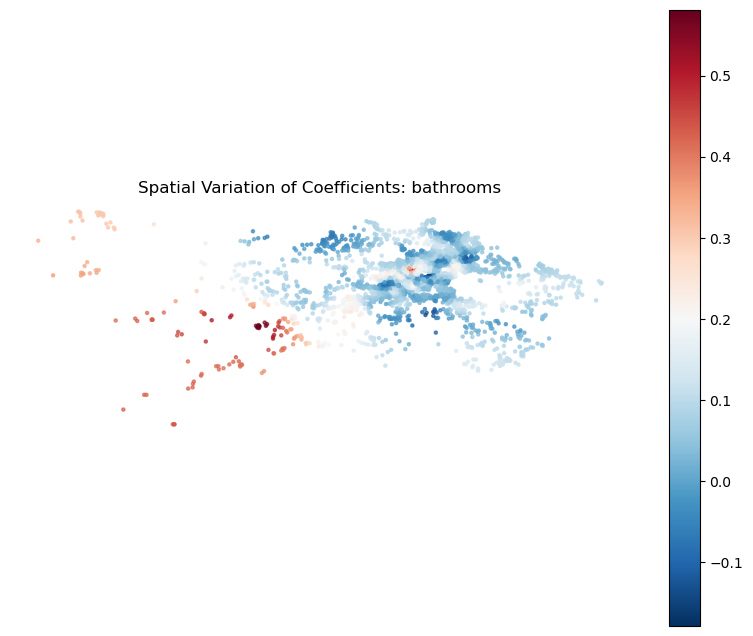

In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_plot = gpd.GeoDataFrame(
    df_clean, 
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude), 
    crs="EPSG:4326"
)

col_name = 'coef_' + variable_names[3]
gdf_plot[col_name] = gwr_results.params[:, 4]

fig, ax = plt.subplots(figsize=(10, 8))

gdf_plot.plot(column=col_name, 
              ax=ax, 
              legend=True, 
              cmap='RdBu_r', 
              markersize=5,      
              alpha=0.7,         
              aspect=1)         

plt.title("Spatial Variation of Coefficients: " + variable_names[3], fontsize=12)
plt.axis('off')
plt.show()

In [42]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mgwr.utils import shift_colormap,truncate_colormap
from matplotlib import cm,colors

def param_plots(result, gdf, names=[], filter_t=False, figsize=(10, 10)):
    
    k = gwr_results.k
    
    fig, axs = plt.subplots(int(k/2)+1, 2, figsize=figsize)
    axs = axs.ravel()
    
    vmin = -0.8
    vmax = 0.8
    
    cmap = cm.get_cmap("bwr_r")
    norm = colors.BoundaryNorm(np.arange(-0.8,0.9,0.1),ncolors=256)
    
    for j in range(k):
        
        pd.concat([gdf,pd.DataFrame(np.hstack([result.params,result.bse]))],axis=1).plot(ax=axs[j],column=j,vmin=vmin,vmax=vmax,
                                                                                         cmap=cmap,norm=norm,linewidth=0.1,edgecolor='white',aspect=1)
        axs[j].set_title("Parameter estimates of \n" + names[j],fontsize=10)
        
        if filter_t:
            rslt_filtered_t = result.filter_tvals()
            if (rslt_filtered_t[:,j] == 0).any():
                gdf[rslt_filtered_t[:,j] == 0].plot(color='lightgrey', ax=axs[j],linewidth=0.1,edgecolor='white',aspect=1)
        
        plt.axis('off')
    
    fig = axs[j].get_figure()
    cax = fig.add_axes([0.99, 0.2, 0.025, 0.6])
    sm = plt.cm.ScalarMappable(cmap=cmap,norm=norm)
    
    sm._A = []
    fig.colorbar(sm, cax=cax)

C:\Users\18095\AppData\Local\Temp\ipykernel_36420\1528436211.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr_r")


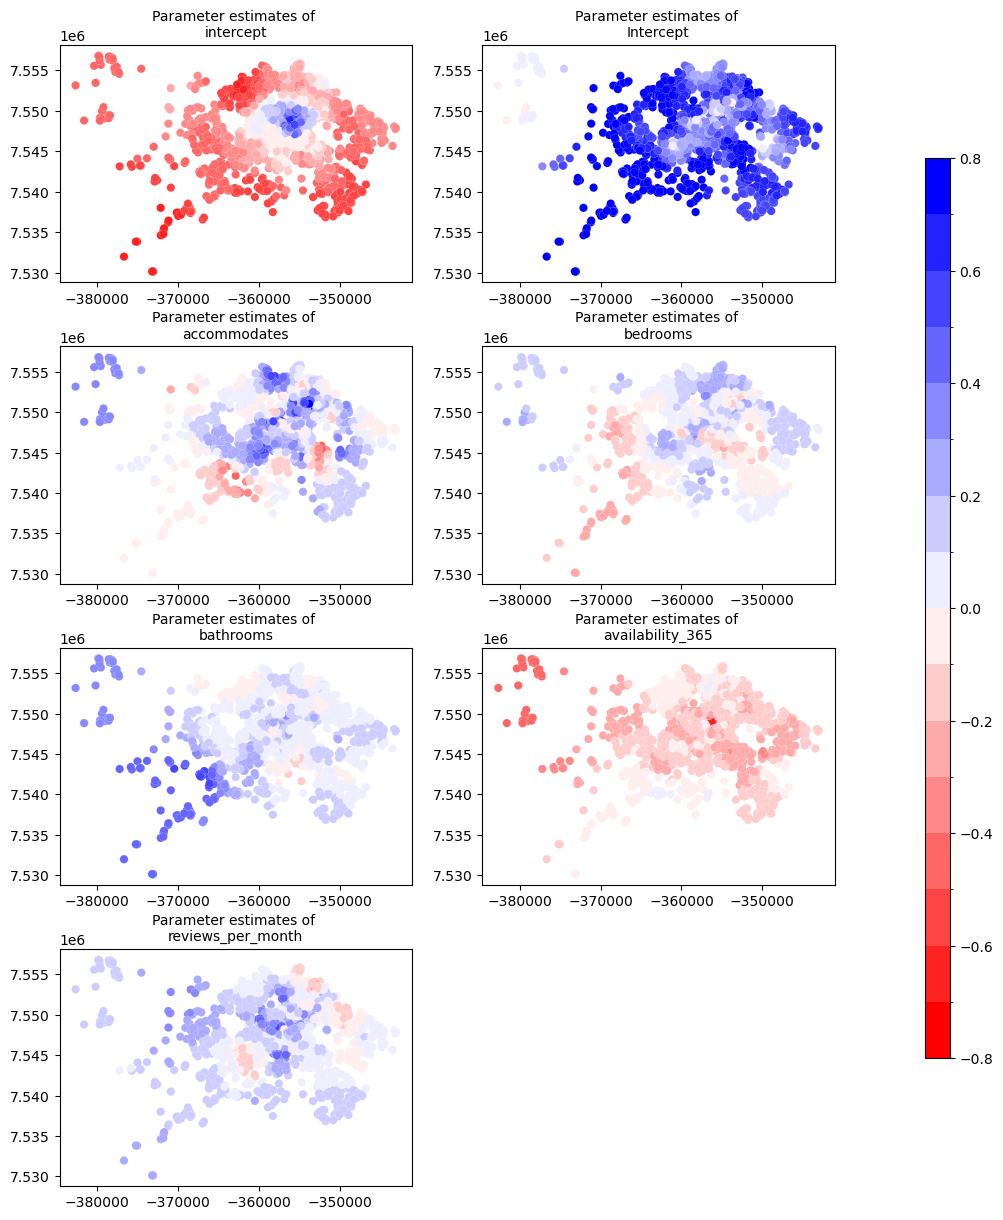

In [43]:
param_plots(gwr_results, gdf, names=['intercept'] + variable_names,figsize = (10,15))

In [44]:
w = Queen.from_dataframe(gdf)

w.transform = 'R'

residual_moran = Moran(gwr_results.resid_response.reshape(-1), w)
residual_moran.I

C:\Users\18095\AppData\Local\Temp\ipykernel_36420\2558387153.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


np.float64(0.059385171555337055)

C:\Users\18095\AppData\Local\Temp\ipykernel_36420\1528436211.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("bwr_r")


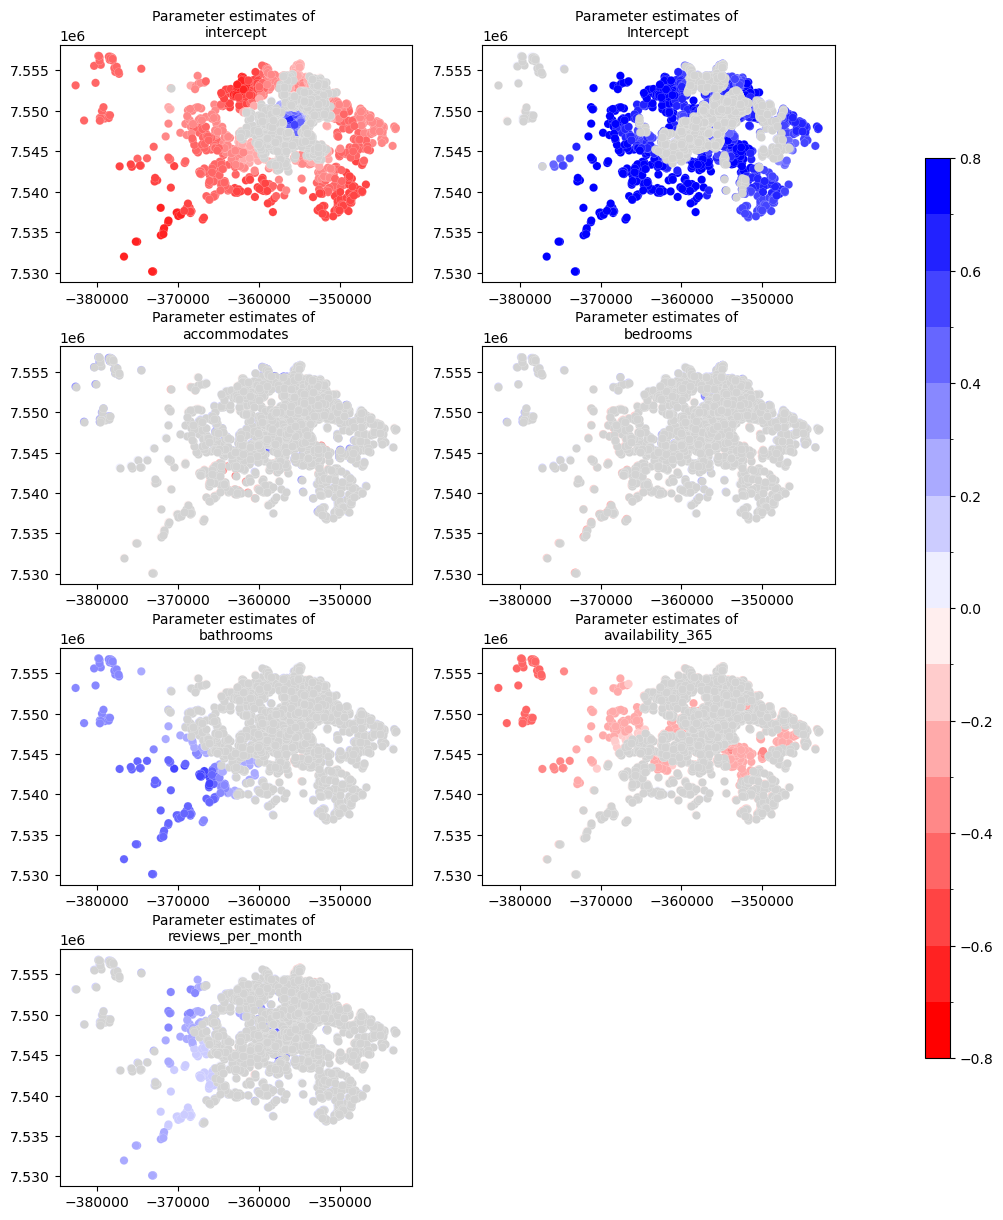

In [45]:
param_plots(gwr_results, gdf, names=['intercept'] + variable_names, figsize = (10,15), filter_t=True)

### MGWR

In [46]:
%%time
mgwr_selector = Sel_BW(coords, y, X, multi=True)
mgwr_bw = mgwr_selector.search(verbose=True)

print("Selected optimal bandwidth is:", mgwr_bw)

Current iteration: 1 ,SOC: 0.003116
Bandwidths: 56.0, 82.0, 132.0, 223.0, 106.0, 149.0, 174.0
Current iteration: 2 ,SOC: 0.0014967
Bandwidths: 47.0, 91.0, 178.0, 309.0, 104.0, 149.0, 190.0
Current iteration: 3 ,SOC: 0.0009727
Bandwidths: 47.0, 94.0, 236.0, 377.0, 101.0, 149.0, 194.0
Current iteration: 4 ,SOC: 0.0007303
Bandwidths: 47.0, 104.0, 285.0, 382.0, 101.0, 149.0, 194.0
Current iteration: 5 ,SOC: 0.0006052
Bandwidths: 47.0, 104.0, 363.0, 382.0, 101.0, 149.0, 194.0
Current iteration: 6 ,SOC: 0.0005172
Bandwidths: 47.0, 104.0, 440.0, 382.0, 101.0, 149.0, 194.0
Current iteration: 7 ,SOC: 0.0004347
Bandwidths: 47.0, 104.0, 512.0, 396.0, 101.0, 149.0, 194.0
Current iteration: 8 ,SOC: 0.0003884
Bandwidths: 47.0, 104.0, 635.0, 398.0, 101.0, 149.0, 194.0
Current iteration: 9 ,SOC: 0.0003579
Bandwidths: 47.0, 104.0, 807.0, 398.0, 101.0, 149.0, 194.0
Current iteration: 10 ,SOC: 0.0003077
Bandwidths: 47.0, 104.0, 955.0, 398.0, 101.0, 149.0, 194.0
Current iteration: 11 ,SOC: 0.0003068
Bandw

In [47]:
%%time

mgwr_results = MGWR(coords, y, X, selector=mgwr_selector,name_x=variable_names).fit()

CPU times: total: 47min 43s
Wall time: 4min 14s


In [48]:
mgwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                4553
Number of covariates:                                                     7

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           2478.716
Log-likelihood:                                                   -5076.211
AIC:                                                              10166.423
AICc:                                                             10168.455
BIC:                                                             -35814.704
R2:                                                                   0.456
Adj. R2:                                                              0.455

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

#### The multiscale geographically weighted regression (MGWR) model was estimated to further explore spatial heterogeneity in the determinants of Airbnb prices. Compared with both the global regression model and the GWR model, MGWR provides an improved model fit.

#### First, the diagnostic statistics indicate that MGWR performs better than the global regression model and slightly better than the GWR model. The R² increases from 0.456 in the global model and 0.692 in the GWR model to 0.725 in the MGWR model. Similarly, the AIC value decreases from 10166.423 (global model) and 8550.980 (GWR) to 8362.252 in the MGWR model. These results suggest that allowing each variable to operate at different spatial scales improves the explanatory power of the model.

#### Second, the MGWR model reveals that different explanatory variables operate at different spatial scales. For example, the bandwidth for accommodates is 104, indicating that the influence of accommodation capacity varies at a relatively local spatial scale. In contrast, the bandwidth for bedrooms is very large (2121), suggesting that the effect of bedrooms is relatively stable across the study area and behaves more like a global relationship.

#### Other variables such as availability_365 and reviews_per_month have intermediate bandwidths, indicating that their effects vary across space but at a broader spatial scale compared with highly localized variables. This highlights the advantage of MGWR in capturing multi-scale spatial processes that cannot be represented by a single bandwidth.

#### Finally, the summary statistics of the parameter estimates confirm the presence of spatial heterogeneity. For example, the coefficient of accommodates ranges from −0.277 to 0.971, suggesting that the impact of accommodation capacity on Airbnb prices differs substantially across locations. Similarly, the effect of availability_365 varies spatially, with coefficients ranging from −0.272 to 0.804.

#### Overall, the MGWR model provides the best model performance and offers a more flexible representation of spatial relationships by allowing each explanatory variable to operate at its own spatial scale.

In [49]:
w = Queen.from_dataframe(gdf)

w.transform = 'R'

residual_moran = Moran(mgwr_results.resid_response.reshape(-1), w)
residual_moran.I

C:\Users\18095\AppData\Local\Temp\ipykernel_36420\1198929227.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


np.float64(-0.01999296802765297)

In [50]:
from esda.moran import Moran
moran_ols = Moran(ols.u, w_knn)

print("OLS Moran's I:", moran_ols.I)
moran_gwr = Moran(gwr_results.resid_response, w_knn)

print("GWR Moran's I:", moran_gwr.I)
moran_mgwr = Moran(mgwr_results.resid_response, w_knn)

print("MGWR Moran's I:", moran_mgwr.I)

comparison = pd.DataFrame({
    "OLS": [
        ols.r2,
        ols.aic,
        moran_ols.I
    ],
    "GWR": [
        gwr_results.adj_R2,
        gwr_results.aicc,
        moran_gwr.I
    ],
    "MGWR": [
        mgwr_results.adj_R2,
        mgwr_results.aicc,
        moran_mgwr.I
    ]
},
index=[
    "Adjusted R2",
    "AICc",
    "Moran's I of residuals"
])

comparison

OLS Moran's I: 0.3212416690548603
GWR Moran's I: 0.08137119366516664
MGWR Moran's I: -0.021328434118354774


,OLS,GWR,MGWR
Adjusted R2,0.494227,0.654322,0.678641
AICc,5425.294666,8671.760890,8588.188397
Moran's I of residuals,0.321242,0.081371,-0.021328


#### Based on the results, the OLS model has an adjusted R² of 0.494, indicating limited explanatory power for the dependent variable. Its residuals show significant spatial autocorrelation (Moran’s I = 0.321), suggesting that spatial heterogeneity is not captured. The GWR model, which introduces spatial weighting, increases the adjusted R² to 0.654 and reduces the residual autocorrelation to 0.081, showing improved model fit; however, its AICc is relatively high (8671.76), reflecting increased model complexity. The MGWR model further accounts for multiscale effects, achieving the highest adjusted R² of 0.679 and a lower AICc of 8588.19, while its residual Moran’s I is -0.021, indicating nearly no spatial autocorrelation. Overall, MGWR demonstrates the best performance in both explanatory power and residual spatial independence, capturing variable effects across different spatial scales more accurately and showing clear advantages over OLS and GWR.